# 02 — Baseline: hand-crafted features + Isolation Forest (4 anomaly types)**Goal:** build a simple, interpretable anomaly-detection baseline on the cleaned Porto sample. We extract 8 scalar features per trip, fit Isolation Forest, and evaluate using synthetic anomaly injection across **four** types: detour, GPS jump, noise, and **reversal** (sequence direction flipped).**Inputs:**- `porto_clean.csv` from Drive (saved by notebook 01).**Outputs (saved to Drive):**- `eval_data.pkl` — labeled evaluation set with 4 anomaly types (200 each, 800 total).**About the reversal injection:** reversing a trajectory in time (`pts[::-1]`) is invariant to *all* hand-crafted features — length, speeds, detour ratio, and bounding box are order-independent. So the baseline should score ROC-AUC ≈ 0.5 for reversal (random). TS2Vec, being a sequence model, should pick up the flipped delta signs and detect reversals decisively. This is the cleanest test for TS2Vec's advantage.---## 1. Setup — Drive, paths, reload the cleaned sample

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_DIR = "/content/drive/MyDrive/ADM_project"
CLEAN_PATH  = os.path.join(PROJECT_DIR, "porto_clean.csv")
EVAL_PATH   = os.path.join(PROJECT_DIR, "eval_data.pkl")
FIG_DIR     = PROJECT_DIR

SEED = 42
rng  = np.random.default_rng(SEED)

print("Cleaned file exists:", os.path.exists(CLEAN_PATH))

Cleaned file exists: True


In [3]:
# Load the cleaned sample and parse polylines into numpy arrays
df = pd.read_csv(CLEAN_PATH)
df["pts"] = df["POLYLINE"].apply(lambda s: np.array(json.loads(s)))
df["n_points"] = df["pts"].apply(len)

# Only use trips with enough points to inject anomalies meaningfully
df = df[df["n_points"] >= 10].reset_index(drop=True)
print(f"Loaded {len(df)} trips with >= 10 points")
print(f"Point count: min {df['n_points'].min()}, median {int(df['n_points'].median())}, max {df['n_points'].max()}")

Loaded 54573 trips with >= 10 points
Point count: min 10, median 43, max 360


---## 2. Hand-crafted features (the baseline representation)8 scalar features per trip:| feature           | what it captures                                            ||-------------------|-------------------------------------------------------------|| `length_m`        | total distance traveled (in meters)                          || `n_points`        | duration proxy (× 15 s = seconds)                            || `straight_m`      | origin-to-destination straight-line distance                 || `detour_ratio`    | `length / straight` — high for detours                       || `max_speed`       | biggest segment ÷ 15 s — high for GPS jumps                  || `mean_speed`      | average over the trip                                        || `speed_std`       | speed variability — high for noisy GPS                       || `bbox_diag_m`     | how spread out the trip is geographically                    |**All eight are order-independent** — that's why reversal will be invisible to them.

In [4]:
LAT_TO_M = 111_000
LON_TO_M = 111_000 * np.cos(np.deg2rad(41.16))

FEATURE_NAMES = [
    "length_m", "n_points", "straight_m", "detour_ratio",
    "max_speed", "mean_speed", "speed_std", "bbox_diag_m"
]

def trip_features(pts):
    pts = np.asarray(pts)
    diffs = np.diff(pts, axis=0)
    dx = diffs[:, 0] * LON_TO_M
    dy = diffs[:, 1] * LAT_TO_M
    seg_m = np.sqrt(dx * dx + dy * dy)

    length_m = seg_m.sum()

    sdx = (pts[-1, 0] - pts[0, 0]) * LON_TO_M
    sdy = (pts[-1, 1] - pts[0, 1]) * LAT_TO_M
    straight_m = np.sqrt(sdx * sdx + sdy * sdy)

    speeds = seg_m / 15.0

    bbox_lon = (pts[:, 0].max() - pts[:, 0].min()) * LON_TO_M
    bbox_lat = (pts[:, 1].max() - pts[:, 1].min()) * LAT_TO_M

    return [
        length_m,
        len(pts),
        straight_m,
        length_m / (straight_m + 1e-9),
        speeds.max(),
        speeds.mean(),
        speeds.std(),
        np.sqrt(bbox_lon ** 2 + bbox_lat ** 2),
    ]

X_all = np.array([trip_features(p) for p in df["pts"].values])
print("Feature matrix shape:", X_all.shape)

Feature matrix shape: (54573, 8)


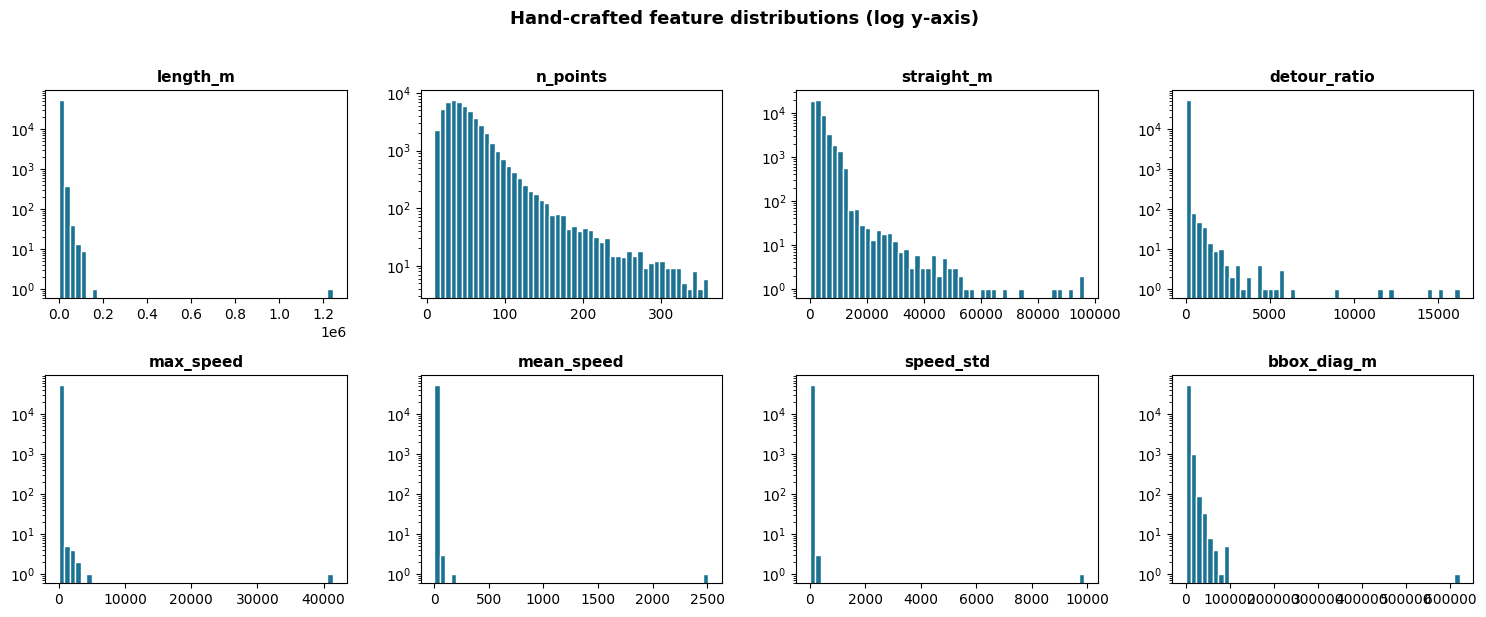

In [5]:
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, col, name in zip(axes.flat, X_all.T, FEATURE_NAMES):
    ax.hist(col, bins=50, color="#1C7293", edgecolor="white")
    ax.set_title(name, fontsize=11, fontweight="bold")
    ax.set_yscale("log")
plt.suptitle("Hand-crafted feature distributions (log y-axis)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

---## 3. Synthetic anomaly injectors — FOUR typesFour functions that take a real trip and corrupt it in different ways:- **detour** — insert a ~2 km loop at the midpoint- **gps_jump** — teleport a single mid-trip point ~3 km away- **noise** — add ~150 m Gaussian noise to every point- **reversal** — flip the entire sequence in timeThe first three change geometry/dynamics in ways that show up in hand-crafted features. Reversal preserves all those statistics but flips the sequence — visible to TS2Vec, invisible to the baseline.

In [6]:
def inject_detour(pts, rng):
    """Insert a loop off the direct route at the trip midpoint (~2 km bump)."""
    pts = np.asarray(pts).copy()
    k = len(pts) // 2
    direction = rng.normal(0, 1, 2)
    direction = direction / (np.linalg.norm(direction) + 1e-9) * 0.02   # ~2.2 km
    loop = pts[k] + direction * np.sin(np.linspace(0, np.pi, 12))[:, None]
    return np.vstack([pts[:k], loop, pts[k:]])

def inject_gps_jump(pts, rng):
    """Teleport a single mid-trip point ~3 km away (GPS recording error)."""
    pts = np.asarray(pts).copy()
    k = rng.integers(len(pts) // 4, max(len(pts) // 4 + 1, 3 * len(pts) // 4))
    pts[k] = pts[k] + rng.normal(0, 1, 2) * 0.03                          # ~3.3 km
    return pts

def inject_noise(pts, rng):
    """Add heavy per-point Gaussian noise (~150 m)."""
    pts = np.asarray(pts).copy()
    return pts + rng.normal(0, 0.0015, size=pts.shape)                    # ~167 m std

def inject_reversal(pts, rng):
    """Flip the trajectory in time. Invariant to all hand-crafted features."""
    return np.asarray(pts).copy()[::-1]

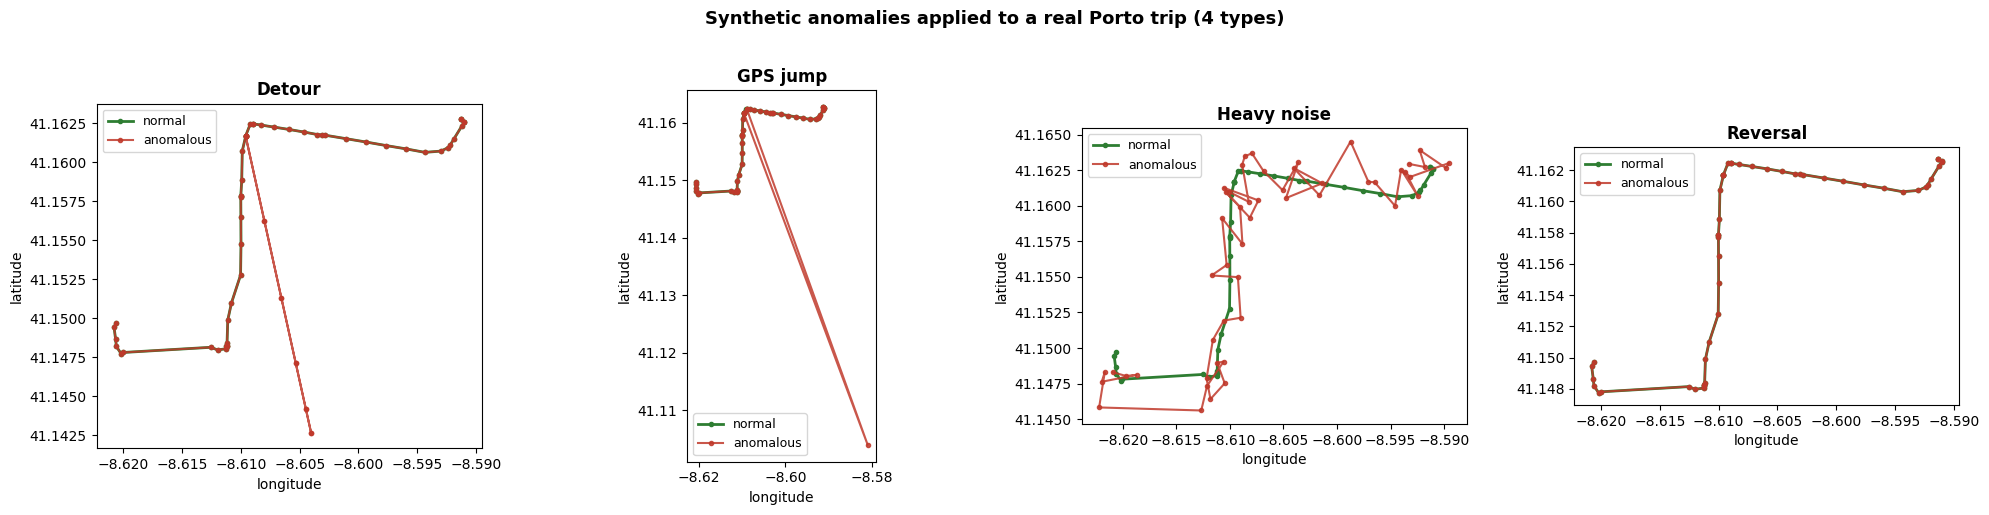

In [7]:
# Visualize all four injectors on one real Porto trip
sample_idx = 12345
example_trip = df["pts"].iloc[sample_idx]
local_rng = np.random.default_rng(SEED)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
configs = [
    ("Detour",      inject_detour(example_trip, local_rng)),
    ("GPS jump",    inject_gps_jump(example_trip, local_rng)),
    ("Heavy noise", inject_noise(example_trip, local_rng)),
    ("Reversal",    inject_reversal(example_trip, local_rng)),
]
for ax, (name, corrupted) in zip(axes, configs):
    ax.plot(example_trip[:, 0], example_trip[:, 1],
            color="#2e7d32", linewidth=2, marker="o", markersize=3, label="normal")
    ax.plot(corrupted[:, 0], corrupted[:, 1],
            color="#c0392b", linewidth=1.5, marker="o", markersize=3, alpha=0.85, label="anomalous")
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("longitude")
    ax.set_ylabel("latitude")
    ax.set_aspect(1 / np.cos(np.deg2rad(41.16)))
    ax.legend(fontsize=9)
plt.suptitle("Synthetic anomalies applied to a real Porto trip (4 types)",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig_anomalies_real.png"), dpi=150, bbox_inches="tight")
plt.show()

For the **reversal** panel, you'll see the green (normal) and red (anomalous) curves traversing identical points — only the start (which becomes the end) and end (which becomes the start) markers swap places. Visually they're almost on top of each other. That's the point: it looks identical to the eye and to the baseline, but the *sequence* of points has flipped.---## 4. Build the labeled evaluation set — 4 types, 200 each1. Randomly pick **800** trips from the cleaned sample.2. Apply each injector to a quarter of them: 200 each of detour, GPS jump, noise, reversal.3. Replace the corrupted trips back into the dataset.4. Every other trip is "normal" (label = 0). The 800 injected ones are "anomaly" (label = 1) plus a string `label_type`.

In [8]:
N = len(df)
N_PER_TYPE = 200

all_indices = rng.permutation(N)
sources = {
    "detour":   all_indices[0 * N_PER_TYPE : 1 * N_PER_TYPE],
    "gps_jump": all_indices[1 * N_PER_TYPE : 2 * N_PER_TYPE],
    "noise":    all_indices[2 * N_PER_TYPE : 3 * N_PER_TYPE],
    "reversal": all_indices[3 * N_PER_TYPE : 4 * N_PER_TYPE],
}

trajectories = list(df["pts"].values)
labels       = np.zeros(N, dtype=int)
label_types  = np.array(["normal"] * N, dtype=object)

injectors = {
    "detour":   inject_detour,
    "gps_jump": inject_gps_jump,
    "noise":    inject_noise,
    "reversal": inject_reversal,
}

for anomaly_type, idxs in sources.items():
    inject_fn = injectors[anomaly_type]
    for i in idxs:
        trajectories[i]  = inject_fn(trajectories[i], rng)
        labels[i]        = 1
        label_types[i]   = anomaly_type

print(f"Total trips:        {N}")
print(f"  Normal:           {(label_types == 'normal').sum()}")
print(f"  Anomalies total:  {labels.sum()}")
for t in ["detour", "gps_jump", "noise", "reversal"]:
    print(f"    {t:10s}      {(label_types == t).sum()}")

Total trips:        54573
  Normal:           53773
  Anomalies total:  800
    detour          200
    gps_jump        200
    noise           200
    reversal        200


---## 5. Re-extract features on the labeled setFeatures should react to most injections but **not to reversal** — that's the key sanity check.

In [9]:
X = np.array([trip_features(p) for p in trajectories])
print("Feature matrix shape:", X.shape)

df_feat = pd.DataFrame(X, columns=FEATURE_NAMES)
df_feat["label_type"] = label_types
print("\nMean of key features per label type:")
print(df_feat.groupby("label_type")[["detour_ratio", "max_speed", "speed_std"]].mean().round(2))

Feature matrix shape: (54573, 8)

Mean of key features per label type:
            detour_ratio  max_speed  speed_std
label_type                                    
detour              5.97      44.94      10.80
gps_jump           13.95     244.52      51.41
noise               6.13      50.99      10.88
normal              9.21      24.98       6.26
reversal            3.80      24.85       5.98


**Critical sanity check:** the row for **reversal** should look essentially identical to **normal** — the means and stds of `detour_ratio`, `max_speed`, `speed_std` should match. If reversal shows different feature values, your injector is broken.For the other three (detour, gps_jump, noise) you should still see clear signal: detour-injected trips have higher `detour_ratio`, GPS-jump trips have higher `max_speed`, noise-injected trips have higher `speed_std`.---## 6. Fit Isolation ForestSame model as before — gets the feature matrix only, no labels.

In [10]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

clf = IsolationForest(
    n_estimators=200,
    contamination="auto",
    random_state=SEED,
    n_jobs=-1,
)
clf.fit(X_scaled)

scores = -clf.score_samples(X_scaled)
print(f"Computed {len(scores)} anomaly scores")
print(f"Score range: [{scores.min():.3f}, {scores.max():.3f}]")

Computed 54573 anomaly scores
Score range: [0.341, 0.842]


---## 7. Evaluation — ROC-AUC and PR-AUC per anomaly typeExpected results: detour/gps_jump/noise all in the 0.7–0.95 range (baseline catches them). **Reversal should land near 0.5** (random) — confirming the feature set is blind to sequence ordering. That zero from the baseline is what TS2Vec will beat.

In [11]:
from sklearn.metrics import roc_auc_score, average_precision_score

print("=" * 60)
print("GLOBAL (all anomalies vs. normal)")
print("=" * 60)
roc_global = roc_auc_score(labels, scores)
pr_global  = average_precision_score(labels, scores)
print(f"  ROC-AUC = {roc_global:.3f}")
print(f"  PR-AUC  = {pr_global:.3f}")

print()
print("=" * 60)
print("PER ANOMALY TYPE (this type only vs. normal)")
print("=" * 60)
per_type = {}
for anomaly_type in ["detour", "gps_jump", "noise", "reversal"]:
    mask = (label_types == "normal") | (label_types == anomaly_type)
    y = labels[mask]
    s = scores[mask]
    roc = roc_auc_score(y, s)
    pr  = average_precision_score(y, s)
    per_type[anomaly_type] = {"roc_auc": roc, "pr_auc": pr}
    print(f"  {anomaly_type:10s}  ROC-AUC = {roc:.3f}   PR-AUC = {pr:.3f}")

GLOBAL (all anomalies vs. normal)
  ROC-AUC = 0.809
  PR-AUC  = 0.086

PER ANOMALY TYPE (this type only vs. normal)
  detour      ROC-AUC = 0.819   PR-AUC = 0.010
  gps_jump    ROC-AUC = 0.970   PR-AUC = 0.125
  noise       ROC-AUC = 0.934   PR-AUC = 0.026
  reversal    ROC-AUC = 0.512   PR-AUC = 0.004


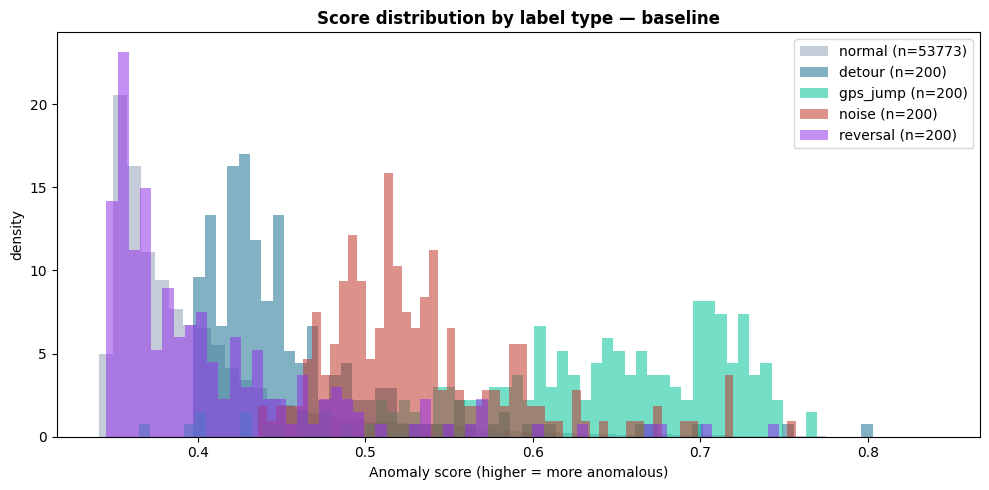

In [12]:
# Score distribution: histogram split by label type — now 5 categories
fig, ax = plt.subplots(figsize=(10, 5))
type_colors = {
    "normal":   "#94a3b8",
    "detour":   "#1C7293",
    "gps_jump": "#02C39A",
    "noise":    "#c0392b",
    "reversal": "#9333ea",   # purple
}
for t in ["normal", "detour", "gps_jump", "noise", "reversal"]:
    mask = label_types == t
    ax.hist(scores[mask], bins=60, alpha=0.55, label=f"{t} (n={mask.sum()})",
            color=type_colors[t], density=True)
ax.set_xlabel("Anomaly score (higher = more anomalous)")
ax.set_ylabel("density")
ax.set_title("Score distribution by label type — baseline", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "fig_baseline_scores.png"), dpi=150, bbox_inches="tight")
plt.show()

**How to read this:** the grey (normal) and purple (reversal) distributions should overlap almost perfectly — confirming the baseline can't tell them apart. The other three colors should be shifted right of the normal peak.---## 8. Save the labeled set + baseline scores for notebook 3Saves the new 4-type evaluation bundle. Notebook 03 will load this and run TS2Vec on the same trips — with reversal included, the comparison will likely give TS2Vec a clear win on at least one anomaly type.

In [13]:
data = {
    "trajectories":     trajectories,
    "labels":           labels,
    "label_types":      label_types,
    "features":         X,
    "feature_names":    FEATURE_NAMES,
    "baseline_scores":  scores,
    "baseline_metrics": {
        "global":   {"roc_auc": roc_global, "pr_auc": pr_global},
        "per_type": per_type,
    },
    "seed": SEED,
}

with open(EVAL_PATH, "wb") as f:
    pickle.dump(data, f)

size_mb = os.path.getsize(EVAL_PATH) / 1024 / 1024
print(f"Saved evaluation bundle to {EVAL_PATH}")
print(f"  size: {size_mb:.1f} MB")
print(f"  trajectories: {len(data['trajectories'])}")
print(f"  features:     {data['features'].shape}")
print(f"  baseline ROC-AUC: {data['baseline_metrics']['global']['roc_auc']:.3f}")
print()
print("Per-type ROC-AUC summary:")
for t, m in data['baseline_metrics']['per_type'].items():
    print(f"  {t:10s}  {m['roc_auc']:.3f}")

Saved evaluation bundle to /content/drive/MyDrive/ADM_project/eval_data.pkl
  size: 47.4 MB
  trajectories: 54573
  features:     (54573, 8)
  baseline ROC-AUC: 0.809

Per-type ROC-AUC summary:
  detour      0.819
  gps_jump    0.970
  noise       0.934
  reversal    0.512


---## Done.**Numbers to record for the report (write them down now):**- Total trips in evaluation set: ~55k- Number of injected anomalies: 200 of each type (800 total)- Baseline global ROC-AUC and PR-AUC- Baseline per-type ROC-AUC and PR-AUC for **all four** types — note that reversal should be ≈ 0.5**Sanity checks before moving on:**- Reversal feature means match normal feature means.- Reversal AUC is close to 0.5 (probably 0.45–0.55).- Score-distribution figure shows reversal histogram overlapping with normal.- The pickle file is on Drive and re-loadable.**Next:** rerun `03_ts2vec.ipynb` and `04_maps_and_analysis.ipynb`. Both load `eval_data.pkl`, so the new data flows through automatically — but both have hardcoded `["detour", "gps_jump", "noise"]` lists in their per-type loops that need `"reversal"` appended. After updating those, run all cells.